In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [13]:
# Load the CSVs
all_vuln_df = pd.read_csv("../data/checklist_data_cleaned.csv")
covered_vuln_df = pd.read_csv("../data/specific_data_cleaned.csv")

In [14]:
# Step 1: Keep only vulnerabilities that exist in all_vuln_df
covered_vuln_df = covered_vuln_df[covered_vuln_df['MASVS Counterpart'].isin(all_vuln_df['Vulnerability'])]

# Step 2: Count how many apps cover each vulnerability
vuln_counts = covered_vuln_df.groupby('MASVS Counterpart')['App Name'].nunique()

# Step 3: Keep only vulnerabilities covered by exactly one app
unique_vulns = vuln_counts[vuln_counts == 1].index

# Step 4: Filter covered_vuln_df to only those unique vulnerabilities
unique_covered_df = covered_vuln_df[covered_vuln_df['MASVS Counterpart'].isin(unique_vulns)]

# Step 5: Count how many unique vulnerabilities each app covers
app_unique_counts = unique_covered_df.groupby('App Name')['MASVS Counterpart'].nunique().sort_values(ascending=False)


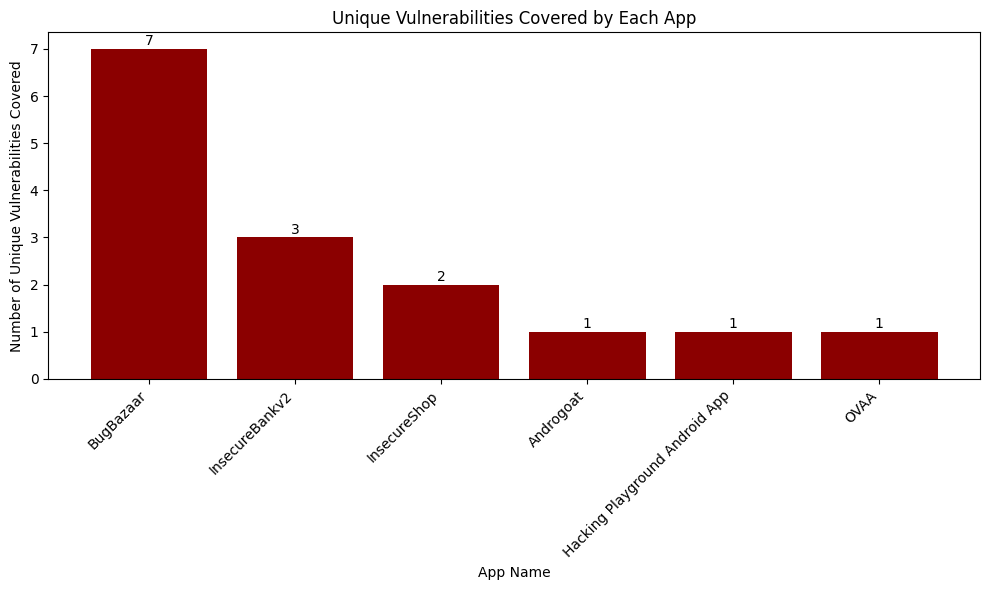

In [15]:
# This one is missing two apps that do not have any unique vulnerabilities

# Step 6: Plot
plt.figure(figsize=(10,6))
bars = plt.bar(app_unique_counts.index, app_unique_counts.values, color='darkred')

# Add counts above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  # x-position: center of the bar
        height + 0.01,                     # y-position: just above the bar
        str(int(height)),                  # label: the count
        ha='center', va='bottom', fontsize=10
    )


plt.ylabel('Number of Unique Vulnerabilities Covered')
plt.xlabel('App Name')
plt.title('Unique Vulnerabilities Covered by Each App')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()


In [16]:
print("Total vulnerabilities in all_vuln_df:", len(all_vuln_df))
print("Total covered vulnerabilities:", len(covered_vuln_df))
print("Number of vulnerabilities covered by exactly 1 app:", (covered_vuln_df.groupby('MASVS Counterpart')['App Name'].nunique() == 1).sum())


Total vulnerabilities in all_vuln_df: 117
Total covered vulnerabilities: 157
Number of vulnerabilities covered by exactly 1 app: 15


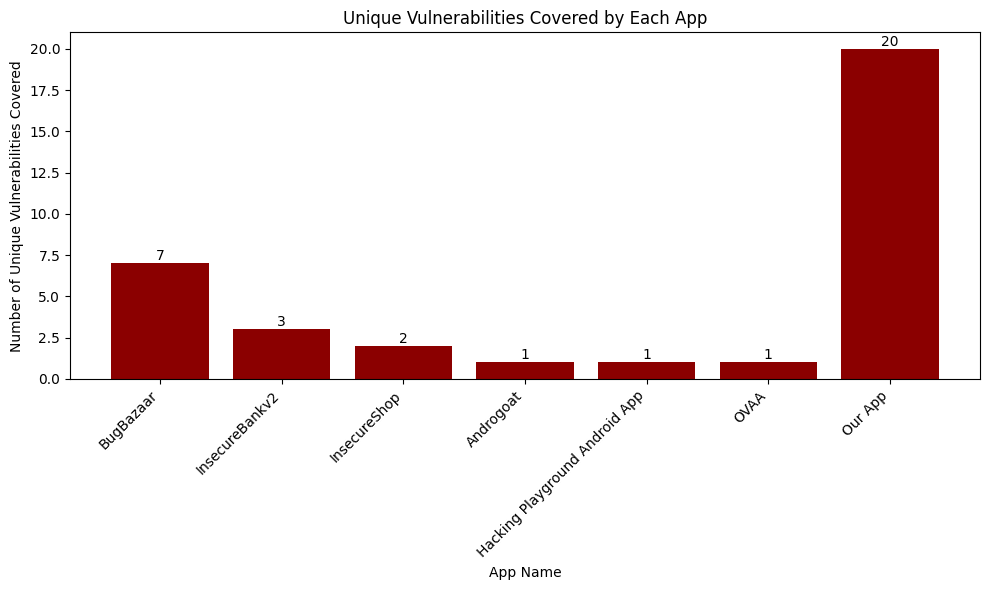

In [17]:
# This one is missing the two apps without unique vulnerabilities
app_unique_counts['Our App'] = 20

# Step 6: Plot
plt.figure(figsize=(10,6))
bars = plt.bar(app_unique_counts.index, app_unique_counts.values, color='darkred')

# Add counts above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  # x-position: center of the bar
        height + 0.01,                     # y-position: just above the bar
        str(int(height)),                  # label: the count
        ha='center', va='bottom', fontsize=10
    )


plt.ylabel('Number of Unique Vulnerabilities Covered')
plt.xlabel('App Name')
plt.title('Unique Vulnerabilities Covered by Each App')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()


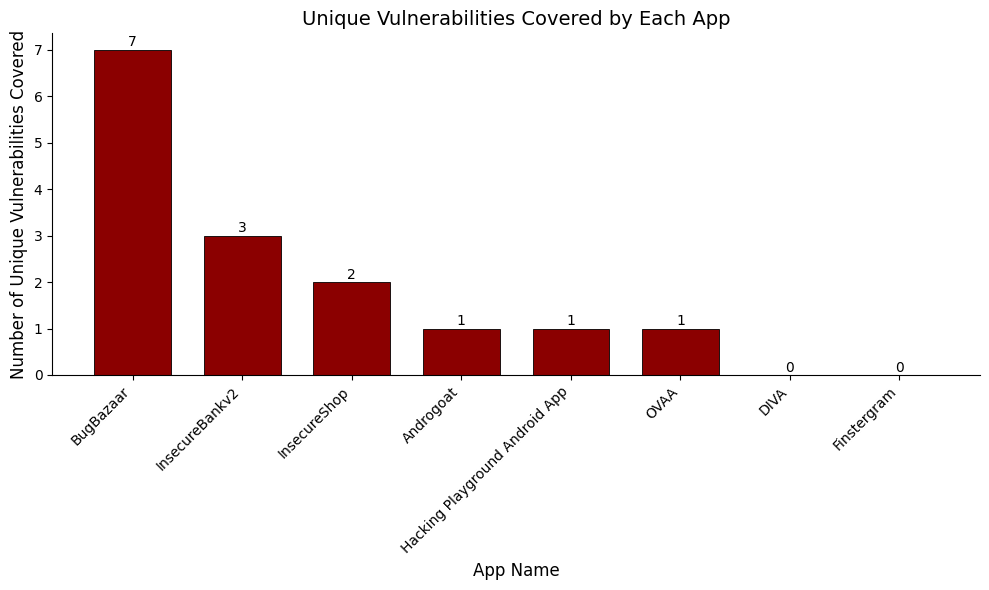

In [18]:
# Step 1: Keep only vulnerabilities that exist in all_vuln_df
covered_vuln_df = covered_vuln_df[
    covered_vuln_df['MASVS Counterpart'].isin(all_vuln_df['Vulnerability'])
]

# Step 2: Count how many apps cover each vulnerability
vuln_counts = covered_vuln_df.groupby('MASVS Counterpart')['App Name'].nunique()

# Step 3: Keep only vulnerabilities covered by exactly one app
unique_vulns = vuln_counts[vuln_counts == 1].index

# Step 4: Filter covered_vuln_df to only those unique vulnerabilities
unique_covered_df = covered_vuln_df[
    covered_vuln_df['MASVS Counterpart'].isin(unique_vulns)
]

# Step 5: Count how many unique vulnerabilities each app covers
app_unique_counts = (
    unique_covered_df
    .groupby('App Name')['MASVS Counterpart']
    .nunique()
)

# Fix: include apps with zero unique vulns
all_apps = covered_vuln_df['App Name'].unique()
app_unique_counts = (
    app_unique_counts
    .reindex(all_apps, fill_value=0)
    .sort_values(ascending=False)
)


# Step 6: Plot
plt.figure(figsize=(10,6))
bars = plt.bar(app_unique_counts.index, app_unique_counts.values, color='darkred', 
               width=0.7, edgecolor="black", linewidth=0.6)

# Add counts above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  # x-position: center of the bar
        height + 0.01,                     # y-position: just above the bar
        str(int(height)),                  # label: the count
        ha='center', va='bottom', fontsize=10
    )

# Styling
plt.title('Unique Vulnerabilities Covered by Each App', fontsize=14)
plt.ylabel('Number of Unique Vulnerabilities Covered', fontsize=12)
plt.xlabel('App Name', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.gca().spines[["top", "right"]].set_visible(False)


plt.tight_layout()

plt.savefig("../plots/coverage_per_app/unique_without_own_app.png", dpi=300, bbox_inches="tight")

plt.show()

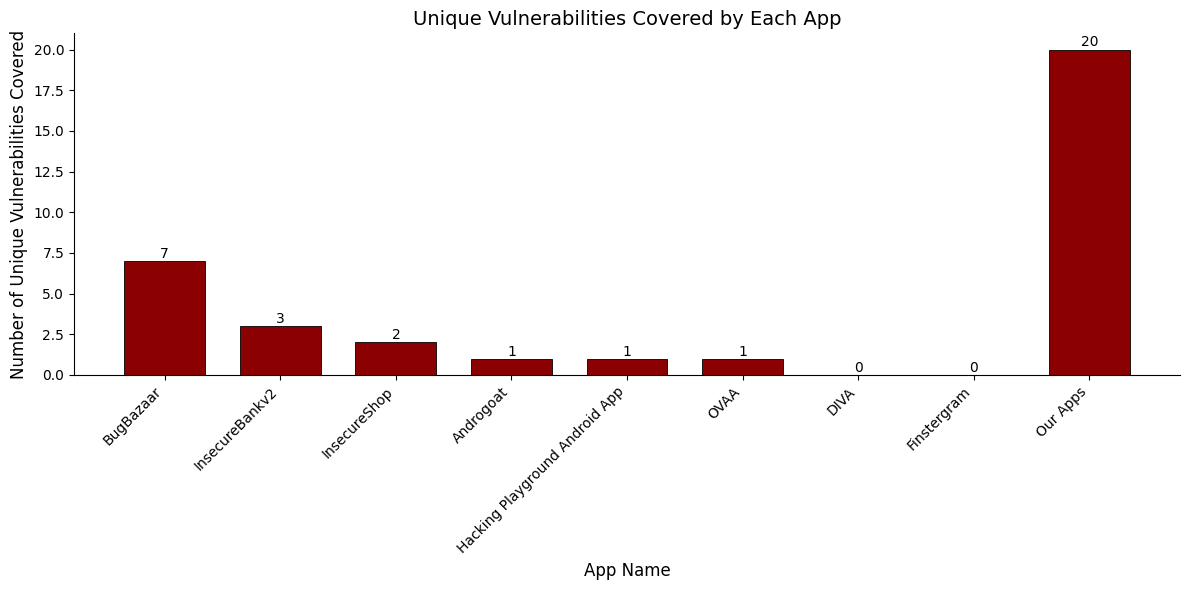

In [19]:
app_unique_counts['Our Apps'] = 20

# Step 6: Plot
plt.figure(figsize=(12,6))
bars = plt.bar(app_unique_counts.index, app_unique_counts.values, color='darkred', width=0.7, edgecolor="black", linewidth=0.6)

# Add counts above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  # x-position: center of the bar
        height + 0.01,                     # y-position: just above the bar
        str(int(height)),                  # label: the count
        ha='center', va='bottom', fontsize=10
    )

# Styling
plt.ylabel('Number of Unique Vulnerabilities Covered', fontsize=12)
plt.xlabel('App Name', fontsize=12)
plt.title('Unique Vulnerabilities Covered by Each App', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.gca().spines[["top", "right"]].set_visible(False)

plt.tight_layout()


plt.savefig("../plots/coverage_per_app/unique_with_own_app.png", dpi=300, bbox_inches="tight")

plt.show()

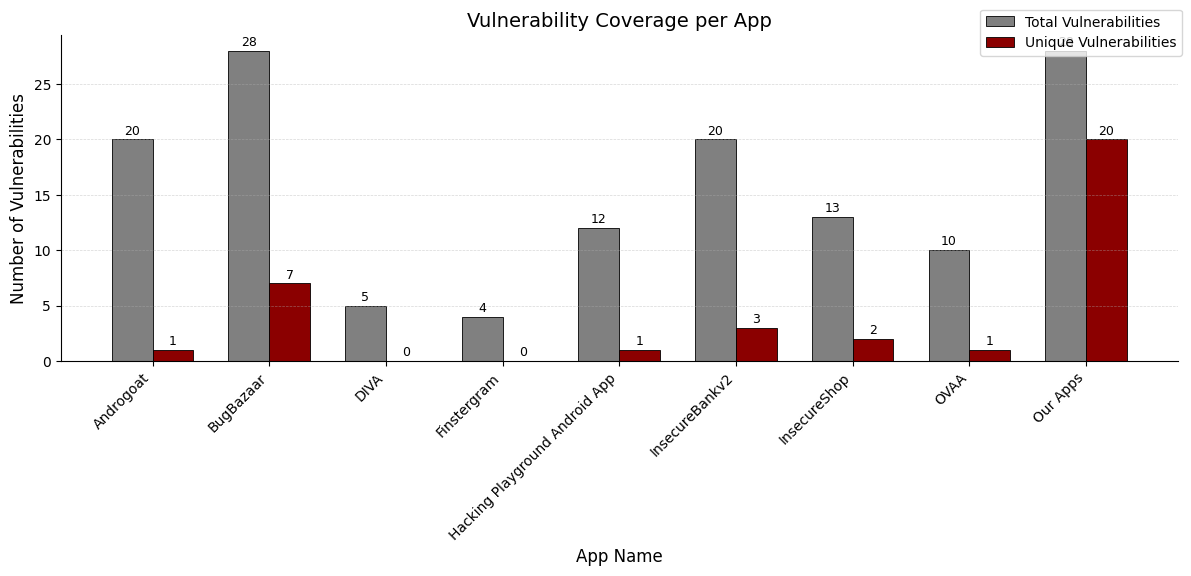

In [20]:
# Load the CSVs
all_vuln_df = pd.read_csv("../data/checklist_data_cleaned.csv")
covered_vuln_df = pd.read_csv("../data/specific_data_cleaned.csv")

# Step 1: Normalize column names
covered_vuln_df['MASVS Counterpart'] = covered_vuln_df['MASVS Counterpart'].str.strip()
all_vuln_df['Vulnerability'] = all_vuln_df['Vulnerability'].str.strip()

# Step 2: Keep only vulnerabilities in all_vuln_df
covered_vuln_df = covered_vuln_df[covered_vuln_df['MASVS Counterpart'].isin(all_vuln_df['Vulnerability'])]

# Step 3: Count how many apps cover each vulnerability
vuln_counts = covered_vuln_df.groupby('MASVS Counterpart')['App Name'].nunique()

# Step 4: Find unique vulnerabilities (covered by exactly 1 app)
unique_vulns = vuln_counts[vuln_counts == 1].index

# Step 5: Count total vulnerabilities per app
total_counts = covered_vuln_df.groupby('App Name')['MASVS Counterpart'].nunique()

# Step 6: Count unique vulnerabilities per app
unique_counts = covered_vuln_df[covered_vuln_df['MASVS Counterpart'].isin(unique_vulns)]
unique_counts = unique_counts.groupby('App Name')['MASVS Counterpart'].nunique()

# Step 7: Add your own app manually
total_counts['Our Apps'] = 28
unique_counts['Our Apps'] = 20

# Step 8: Align apps and sort by total vulnerabilities
apps = total_counts.index.union(unique_counts.index)
total_counts = total_counts.reindex(apps, fill_value=0)
unique_counts = unique_counts.reindex(apps, fill_value=0)

# Step 9: Plot
x = np.arange(len(apps))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, total_counts.values, width, label="Total Vulnerabilities",
               color="gray", edgecolor="black", linewidth=0.6)
bars2 = ax.bar(x + width/2, unique_counts.values, width, label="Unique Vulnerabilities",
               color="darkred", edgecolor="black", linewidth=0.6)

# Titles and labels
ax.set_title("Vulnerability Coverage per App", fontsize=14)
ax.set_xlabel("App Name", fontsize=12)
ax.set_ylabel("Number of Vulnerabilities", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(apps, rotation=45, ha="right")
ax.legend(loc="upper right", bbox_to_anchor=(1.01, 1.1), frameon=True)
ax.grid(axis="y", linestyle="--", alpha=0.5, linewidth=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Annotate bars with counts
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.2,
                f"{int(height)}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# Save figure
fig.savefig("../plots/coverage_per_app/total_vs_unique_with_own_app.png", dpi=300, bbox_inches="tight")